In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [ ]:
path_file = r'train.csv'
df = pd.read_csv(path_file)
display(df.head(), df.shape)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K.
1,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,<=50K
2,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,<=50K
3,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
4,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,<=50K


(39073, 15)

In [3]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,39073.000000,3.907300e+04,39073.000000,39073.000000,39073.000000,39073.000000
mean,38.643488,1.899922e+05,10.069844,1038.040540,86.807949,40.476877
std,13.685634,1.054768e+05,2.574387,7204.953114,401.276773,12.401251
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.177670e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.786150e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.383290e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             39073 non-null  int64 
 1   workclass       38304 non-null  object
 2   fnlwgt          39073 non-null  int64 
 3   education       39073 non-null  object
 4   education-num   39073 non-null  int64 
 5   marital-status  39073 non-null  object
 6   occupation      38302 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital-gain    39073 non-null  int64 
 11  capital-loss    39073 non-null  int64 
 12  hours-per-week  39073 non-null  int64 
 13  native-country  38851 non-null  object
 14  income          39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.5+ MB


In [5]:
df.isnull().sum()

age                 0
workclass         769
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        771
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    222
income              0
dtype: int64

In [6]:
for col in df.columns:
    print(col, (df[col] == '?').sum())

age 0
workclass 1464
fnlwgt 0
education 0
education-num 0
marital-status 0
occupation 1470
relationship 0
race 0
sex 0
capital-gain 0
capital-loss 0
hours-per-week 0
native-country 466
income 0


In [7]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [8]:
print(list(num_cols))

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [9]:
print(list(cat_cols))

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [10]:
print(df['income'].value_counts())

income
<=50K     19733
<=50K.     9991
>50K       6306
>50K.      3043
Name: count, dtype: int64


In [11]:
df_corr = df.copy()
df_corr['income_bool'] = ((df_corr['income'] == '>50K') | (df_corr['income'] == '>50K.')).astype(int)
df_corr.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_bool
0,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K.,0
1,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,<=50K,0
2,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,<=50K,0
3,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0
4,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,<=50K,0


In [12]:
print(df_corr['income_bool'].value_counts())

income_bool
0    29724
1     9349
Name: count, dtype: int64


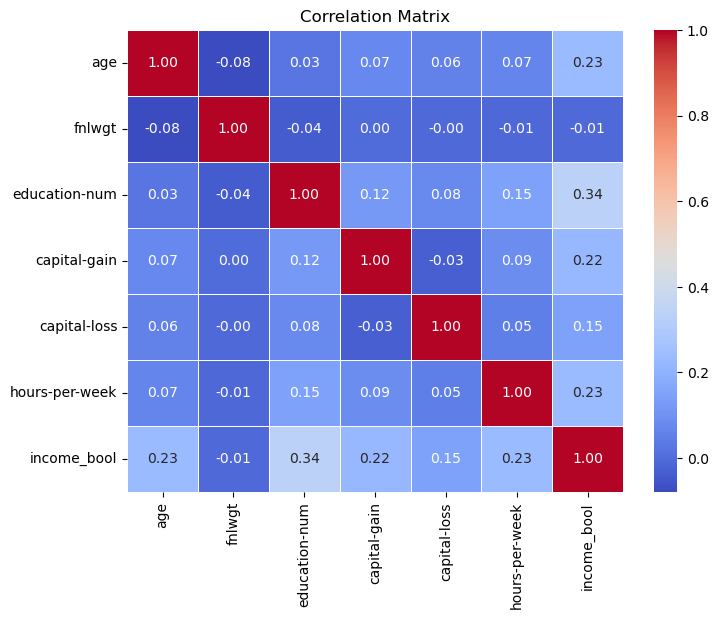

In [13]:
plt.figure(figsize=(8, 6))
corr = df_corr[list(num_cols) + ['income_bool']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Text(0.5, 0.98, 'Histogram of Numerical Columns')

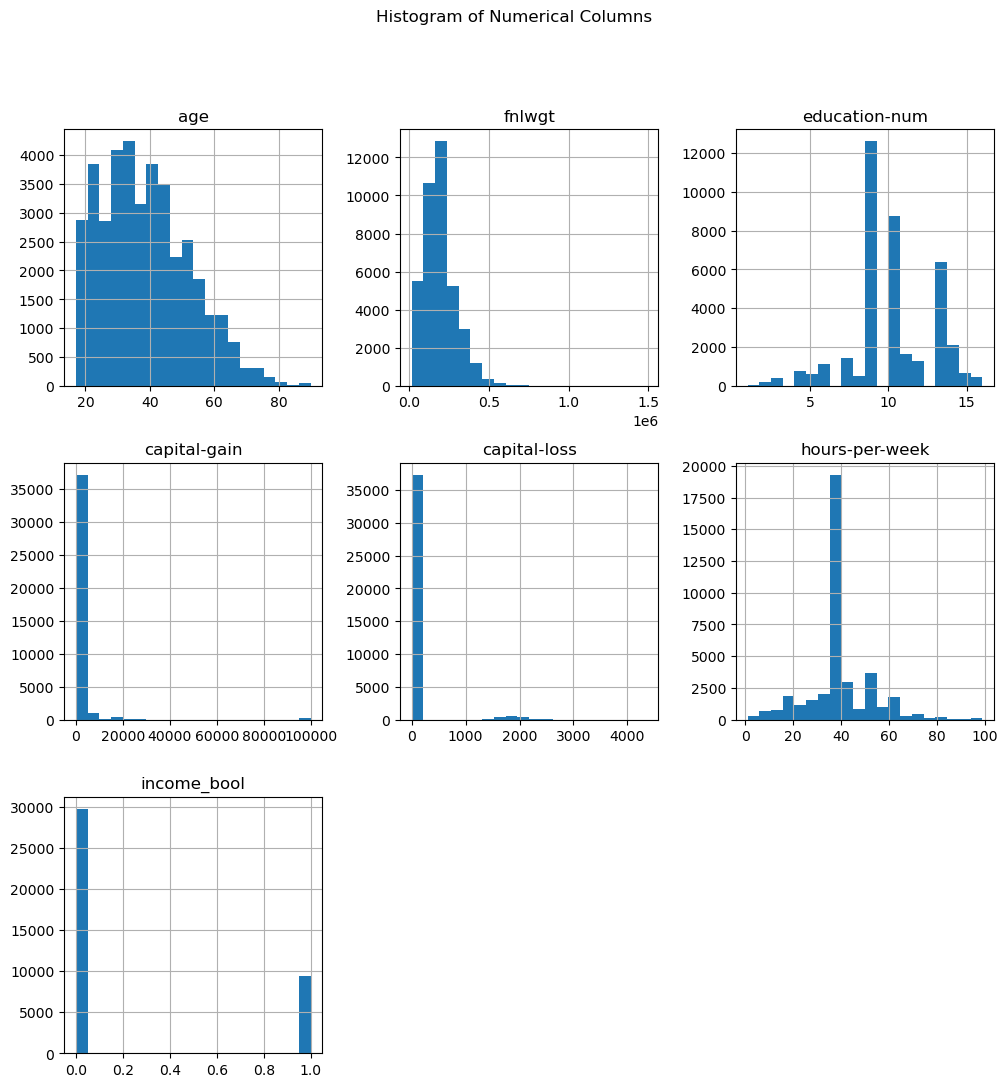

In [14]:
df_corr.hist(figsize=(12, 12), layout=(3, 3), sharex=False, bins=20)
plt.suptitle("Histogram of Numerical Columns")

Text(0.5, 0.98, 'Boxplot of Numerical Columns')

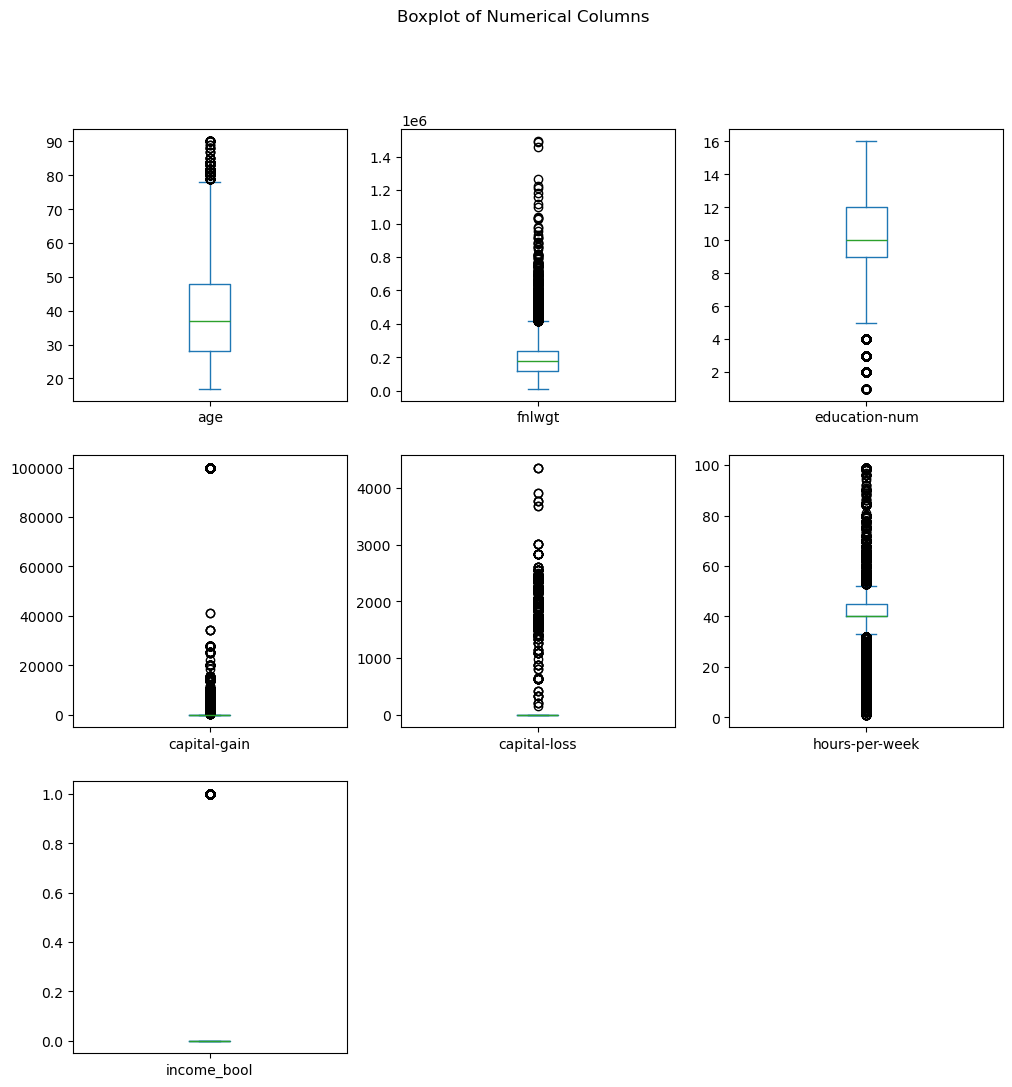

In [15]:
df_corr.plot(kind='box', subplots=True, figsize=(12, 12), sharex=False, layout=(3, 3), sharey=False)
plt.suptitle("Boxplot of Numerical Columns")

Text(0.5, 1.02, 'Pair Plot')

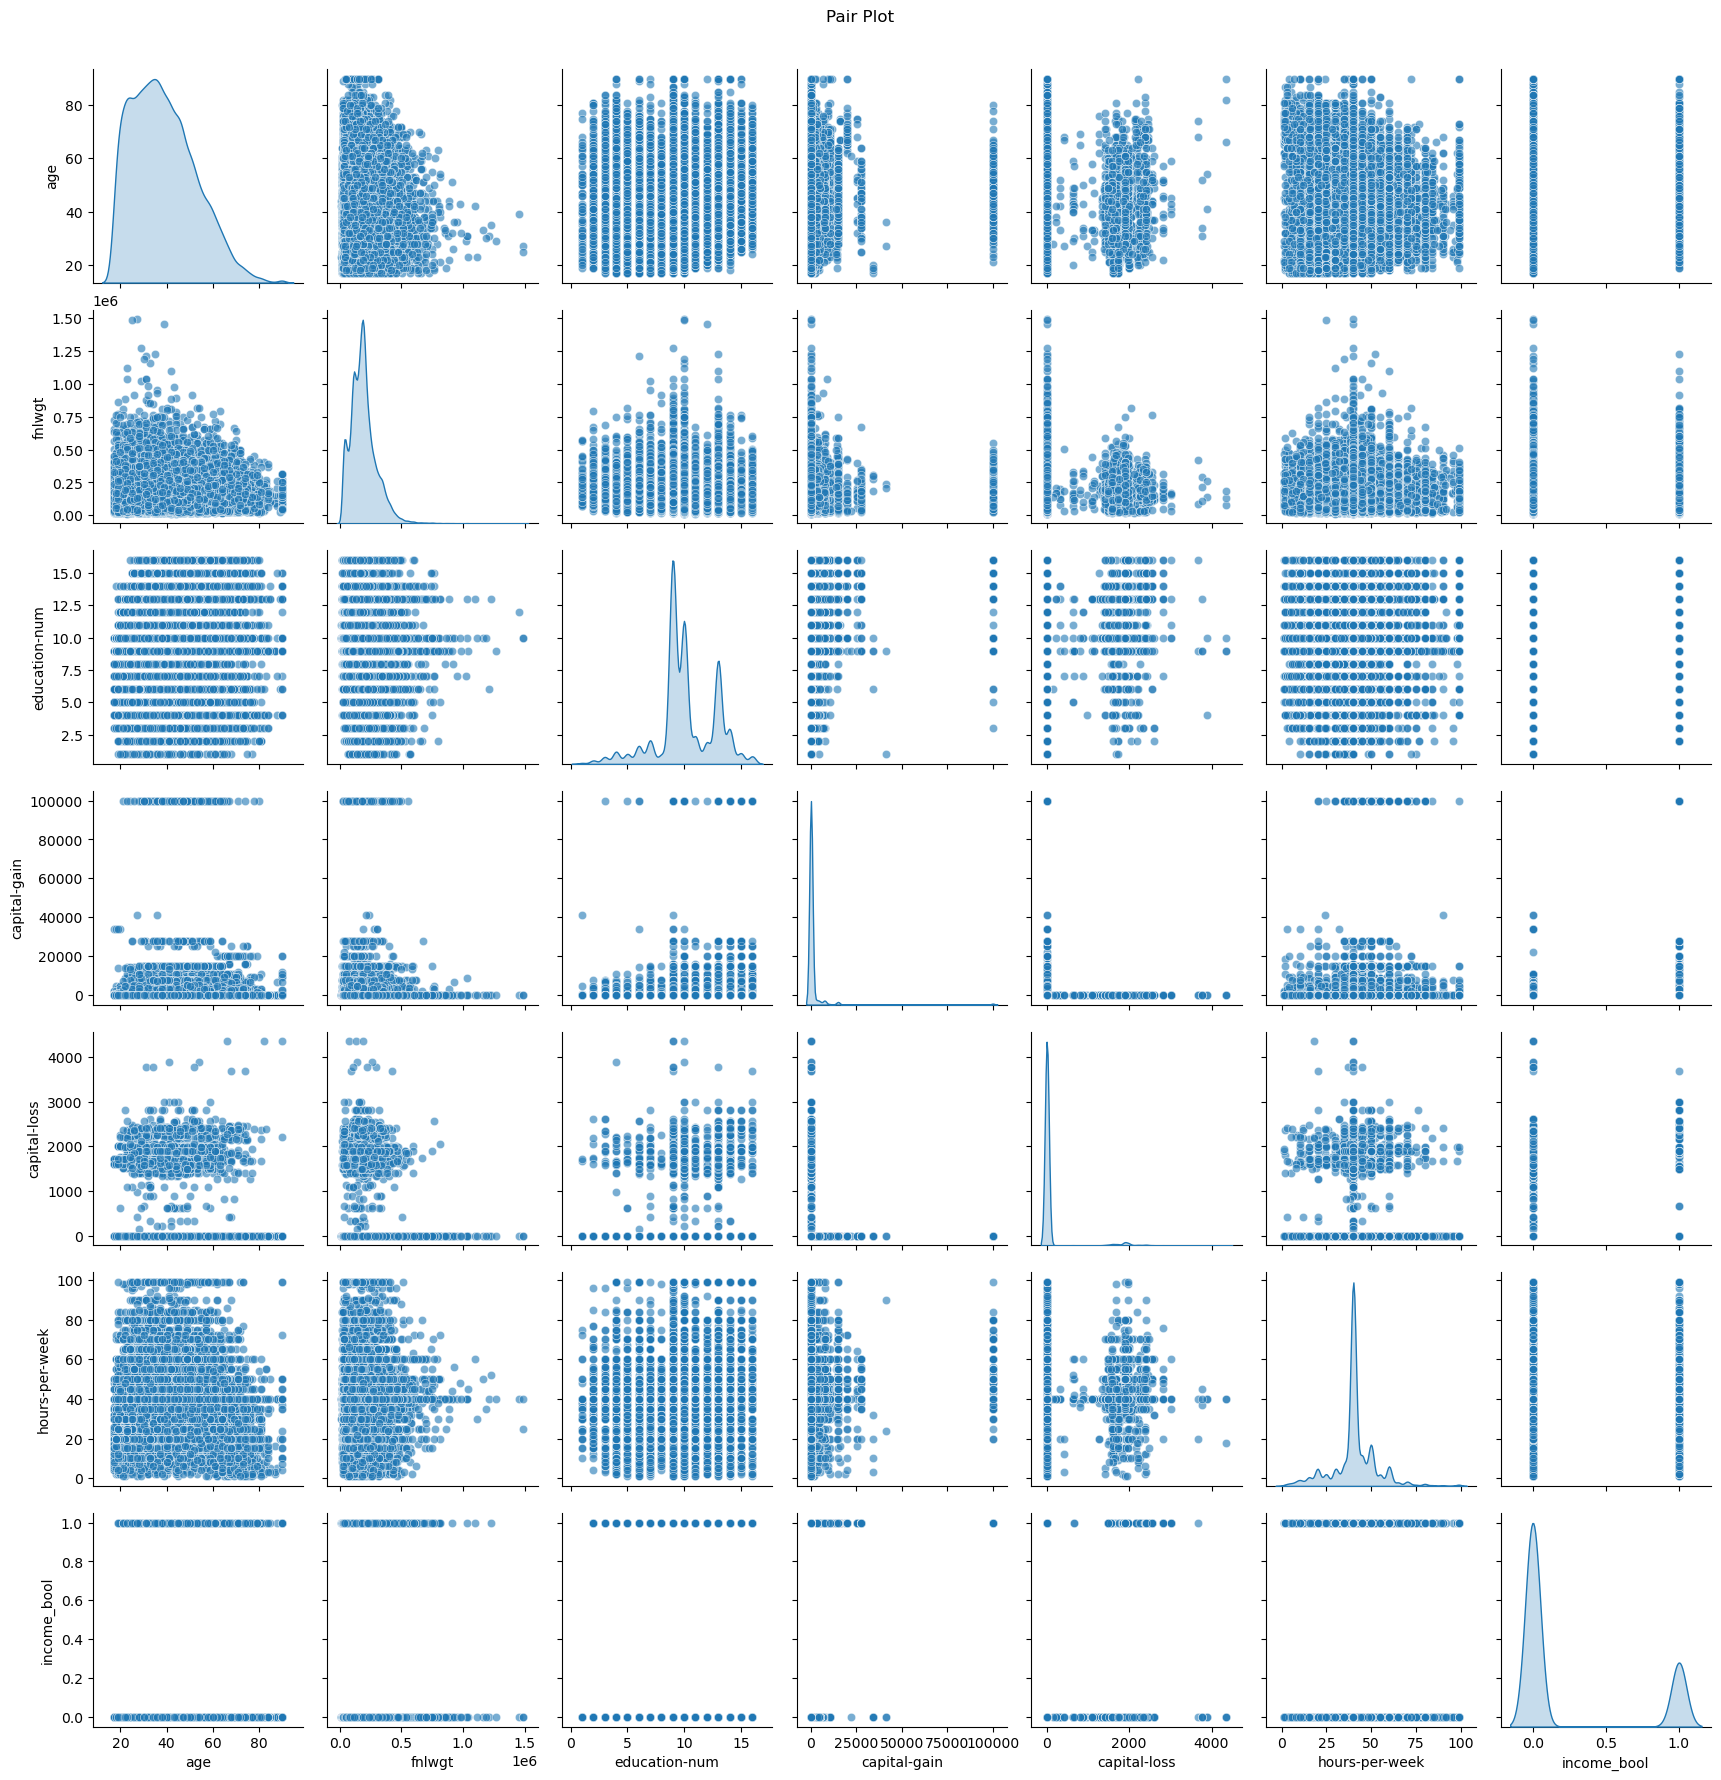

In [16]:
grid = sns.pairplot(
    df_corr[list(num_cols) + ['income_bool']],
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pair Plot', y=1.02)

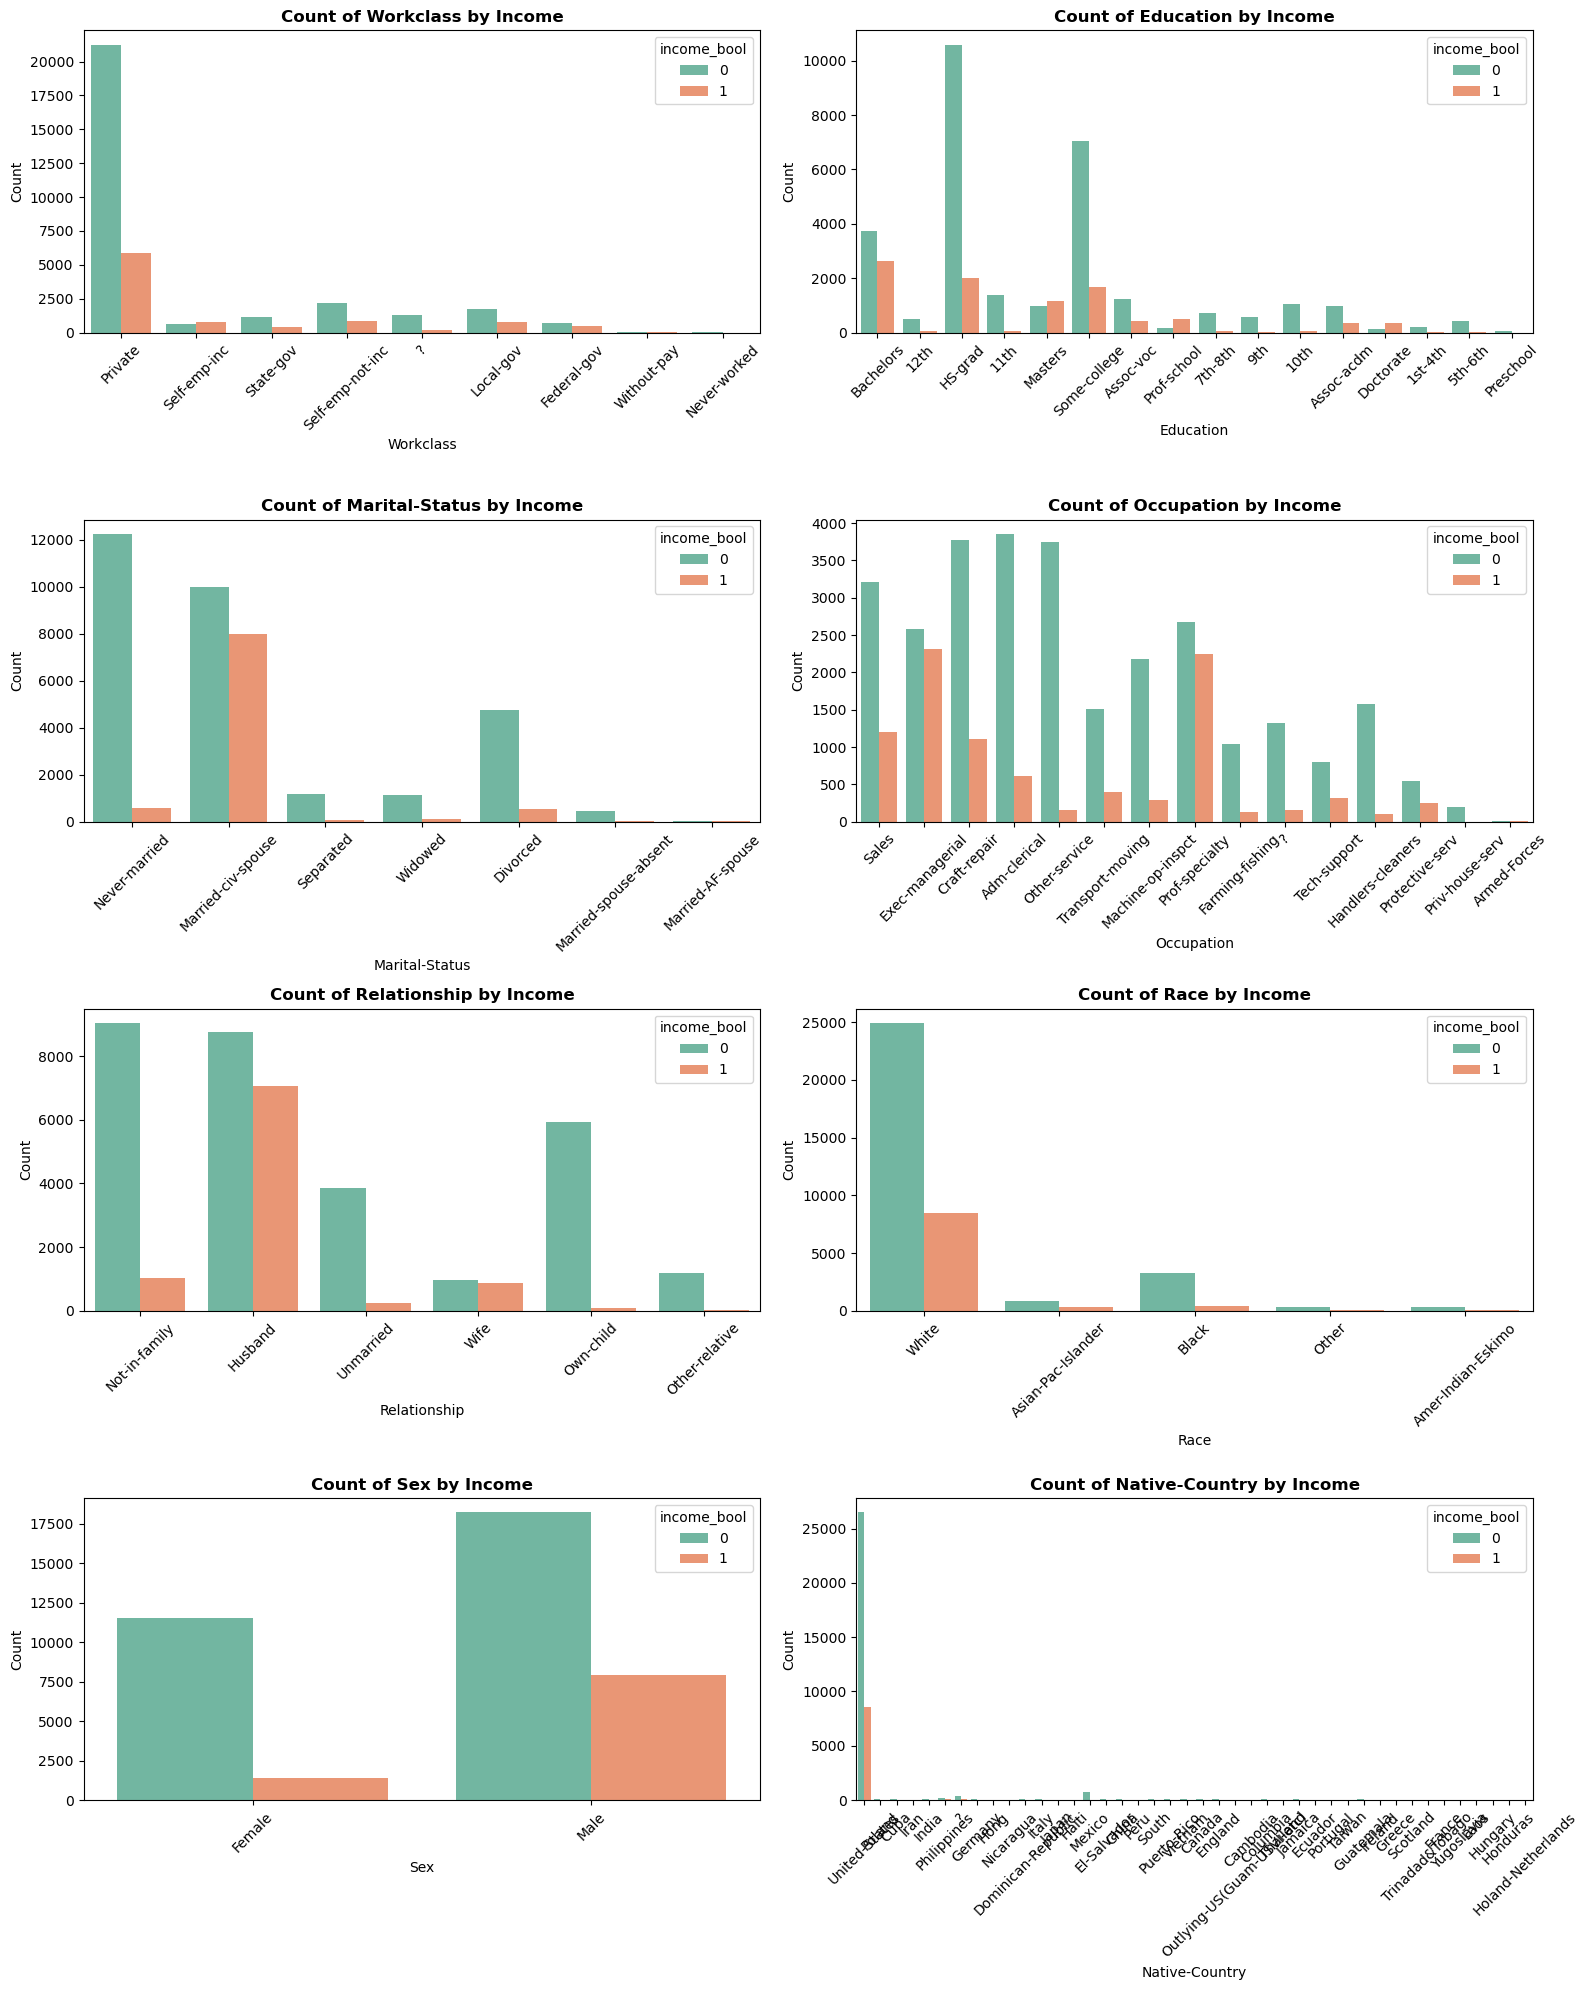

In [17]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'sex', 'native-country']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_corr, x=col, hue="income_bool", ax=axes[i], palette="Set2")
    axes[i].set_title(f"Count of {col.title()} by Income", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.title(), fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Preprocessing

In [18]:
print('Before dropping null values and "?":', df.shape)
df = df[df != '?']
df.dropna(inplace=True)
print('After dropping null values and "?":', df.shape)

Before dropping null values and "?": (39073, 15)
After dropping null values and "?": (36183, 15)


In [19]:
df['income'] = df['income'].replace({'>50K': 1, '>50K.': 1, '<=50K': 0, '<=50K.': 0})
df.income.value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_25736\3160428401.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'>50K': 1, '>50K.': 1, '<=50K': 0, '<=50K.': 0})


income
0    27216
1     8967
Name: count, dtype: int64

In [20]:
cat_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [21]:
print(df.shape)
df_encoded = pd.get_dummies(df, columns=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country'], drop_first=True)
print(df_encoded.shape)
df_encoded.head(10)

(36183, 15)
(36183, 97)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,37,193106,13,0,0,30,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,56,216636,8,0,1651,40,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,53,126977,9,0,0,35,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,72,205343,7,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,46,106705,14,0,0,38,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,42,159911,9,0,0,24,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,28,96020,13,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
7,25,252752,10,0,0,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
8,44,213934,9,2829,0,42,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
9,33,67482,11,0,0,99,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [22]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36183 entries, 0 to 39072
Data columns (total 97 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        36183 non-null  int64
 1   fnlwgt                                     36183 non-null  int64
 2   education-num                              36183 non-null  int64
 3   capital-gain                               36183 non-null  int64
 4   capital-loss                               36183 non-null  int64
 5   hours-per-week                             36183 non-null  int64
 6   income                                     36183 non-null  int64
 7   workclass_Local-gov                        36183 non-null  bool 
 8   workclass_Private                          36183 non-null  bool 
 9   workclass_Self-emp-inc                     36183 non-null  bool 
 10  workclass_Self-emp-not-inc                 36183 no

In [23]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36183 entries, 0 to 39072
Data columns (total 97 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        36183 non-null  int64
 1   fnlwgt                                     36183 non-null  int64
 2   education-num                              36183 non-null  int64
 3   capital-gain                               36183 non-null  int64
 4   capital-loss                               36183 non-null  int64
 5   hours-per-week                             36183 non-null  int64
 6   income                                     36183 non-null  int64
 7   workclass_Local-gov                        36183 non-null  int64
 8   workclass_Private                          36183 non-null  int64
 9   workclass_Self-emp-inc                     36183 non-null  int64
 10  workclass_Self-emp-not-inc                 36183 no

In [24]:
df_encoded.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,37,193106,13,0,0,30,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,56,216636,8,0,1651,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,53,126977,9,0,0,35,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,72,205343,7,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,46,106705,14,0,0,38,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [25]:
from sklearn.model_selection import train_test_split
x = df_encoded.drop('income', axis=1)
y = df_encoded['income']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {x_train.shape}")
print(f"Test shape: {x_test.shape}")

Train shape: (28946, 96)
Test shape: (7237, 96)


In [26]:
print('Data distribution in training set:', y_train.value_counts(normalize=True))
print('Data distribution in testing set:', y_test.value_counts(normalize=True))

Data distribution in training set: income
0    0.752159
1    0.247841
Name: proportion, dtype: float64
Data distribution in testing set: income
0    0.752245
1    0.247755
Name: proportion, dtype: float64


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])
print('Numerical columns after scaling:', x_train[num_cols].describe().round(2))
x_train.head()

Numerical columns after scaling:             age    fnlwgt  education-num  capital-gain  capital-loss  \
count  28946.00  28946.00       28946.00      28946.00      28946.00   
mean      -0.00      0.00           0.00         -0.00          0.00   
std        1.00      1.00           1.00          1.00          1.00   
min       -1.63     -1.67          -3.57         -0.15         -0.22   
25%       -0.80     -0.69          -0.44         -0.15         -0.22   
50%       -0.12     -0.11          -0.05         -0.15         -0.22   
75%        0.64      0.46           1.13         -0.15         -0.22   
max        3.89     12.32           2.30         13.79         10.43   

       hours-per-week  
count        28946.00  
mean             0.00  
std              1.00  
min             -3.32  
25%             -0.08  
50%             -0.08  
75%              0.34  
max              4.82  


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34967,0.032542,-0.101446,-0.438047,-0.14625,-0.221172,-0.079953,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
13228,-1.480158,-1.143133,-2.004265,-0.14625,-0.221172,-1.325368,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
6020,1.545242,0.035231,-0.438047,-0.14625,-0.221172,-0.079953,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
15215,-0.875078,-0.086093,-0.046493,-0.14625,-0.221172,-0.910230,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
38849,-1.253253,1.510827,1.128171,-0.14625,-0.221172,-0.910230,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


# Training Model

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

model_multi = LogisticRegression()
model_multi.fit(x_train, y_train)
y_pred_multi = model_multi.predict(x_test)

cr_multi = classification_report(y_test, y_pred_multi)
print(f"Classification Report for Multi-feature Logistic Regression Model:\n{cr_multi}")

f1_multi = f1_score(y_test, y_pred_multi, average='macro')
print(f"F1 Score for Multi-feature Logistic Regression Model: {f1_multi:.4f}")

Classification Report for Multi-feature Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      5444
           1       0.74      0.61      0.67      1793

    accuracy                           0.85      7237
   macro avg       0.81      0.77      0.79      7237
weighted avg       0.84      0.85      0.85      7237

F1 Score for Multi-feature Logistic Regression Model: 0.7855


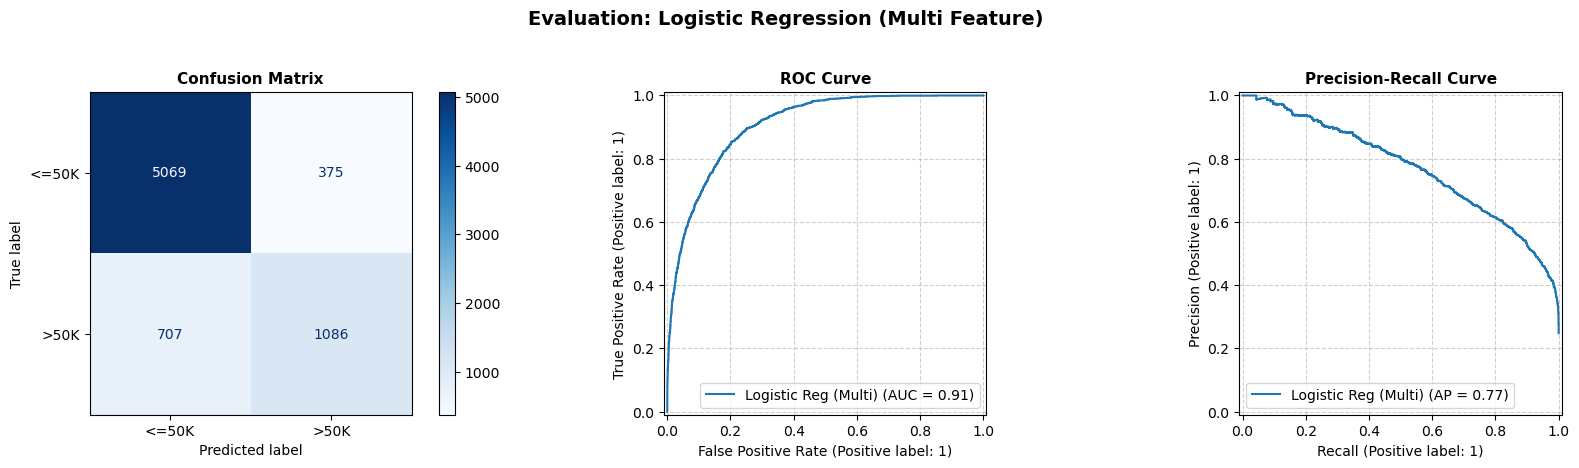

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

x_test_multi = x_test[x_train.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle(
    "Evaluation: Logistic Regression (Multi Feature)",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)

ConfusionMatrixDisplay.from_estimator(
    model_multi,
    x_test_multi,
    y_test,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")

RocCurveDisplay.from_estimator(
    model_multi, x_test_multi, y_test, ax=axes[1], name="Logistic Reg (Multi)"
)
axes[1].set_title("ROC Curve", fontsize=11, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

PrecisionRecallDisplay.from_estimator(
    model_multi, x_test_multi, y_test, ax=axes[2], name="Logistic Reg (Multi)"
)
axes[2].set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)

cr_rf = classification_report(y_test, y_pred_rf)
print(f"Classification Report for Random Forest Model:\n{cr_rf}")

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"F1 Score for Random Forest Model: {f1_rf:.4f}")

Classification Report for Random Forest Model:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      5444
           1       0.74      0.61      0.67      1793

    accuracy                           0.85      7237
   macro avg       0.81      0.77      0.79      7237
weighted avg       0.84      0.85      0.85      7237

F1 Score for Random Forest Model: 0.7873


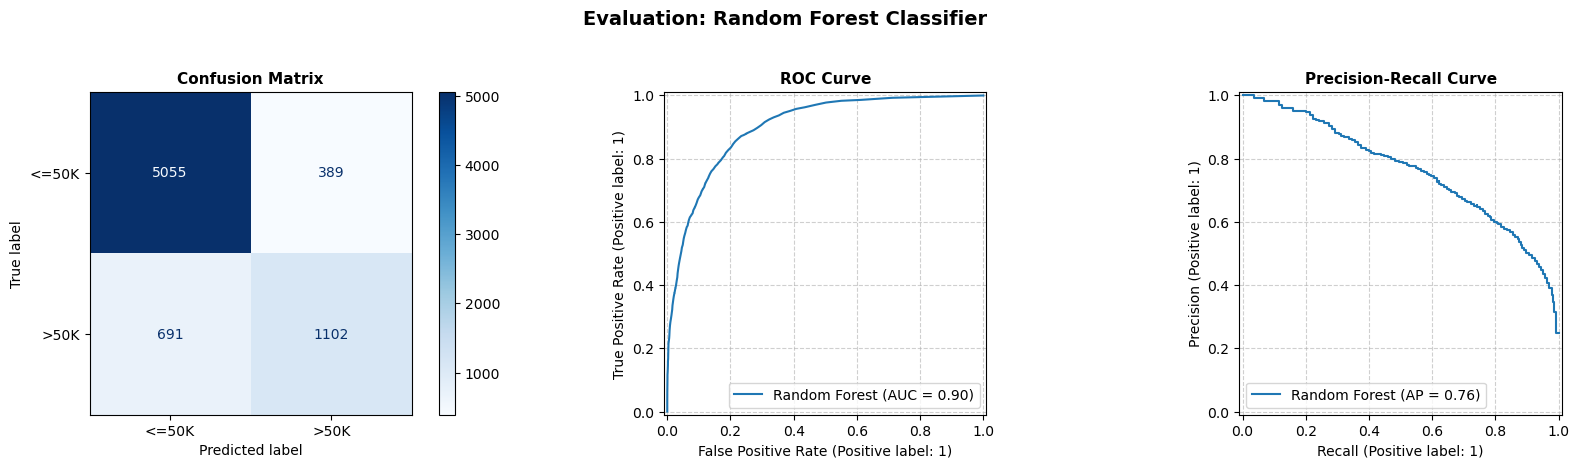

In [31]:
x_test_rf = x_test[model_rf.feature_names_in_]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle(
    "Evaluation: Random Forest Classifier",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)

ConfusionMatrixDisplay.from_estimator(
    model_rf,
    x_test_rf,
    y_test,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")

RocCurveDisplay.from_estimator(
    model_rf, x_test_rf, y_test, ax=axes[1], name="Random Forest"
)
axes[1].set_title("ROC Curve", fontsize=11, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

PrecisionRecallDisplay.from_estimator(
    model_rf, x_test_rf, y_test, ax=axes[2], name="Random Forest"
)
axes[2].set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [32]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

cr_xgb = classification_report(y_test, y_pred_xgb, target_names=['<=50K', '>50K'])
print(f"Classification Report for XGBoost Model:\n{cr_xgb}")

f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
print(f"F1 Score for XGBoost Model: {f1_xgb:.4f}")

Classification Report for XGBoost Model:
              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89      5444
        >50K       0.64      0.83      0.72      1793

    accuracy                           0.84      7237
   macro avg       0.79      0.84      0.80      7237
weighted avg       0.86      0.84      0.85      7237

F1 Score for XGBoost Model: 0.8049


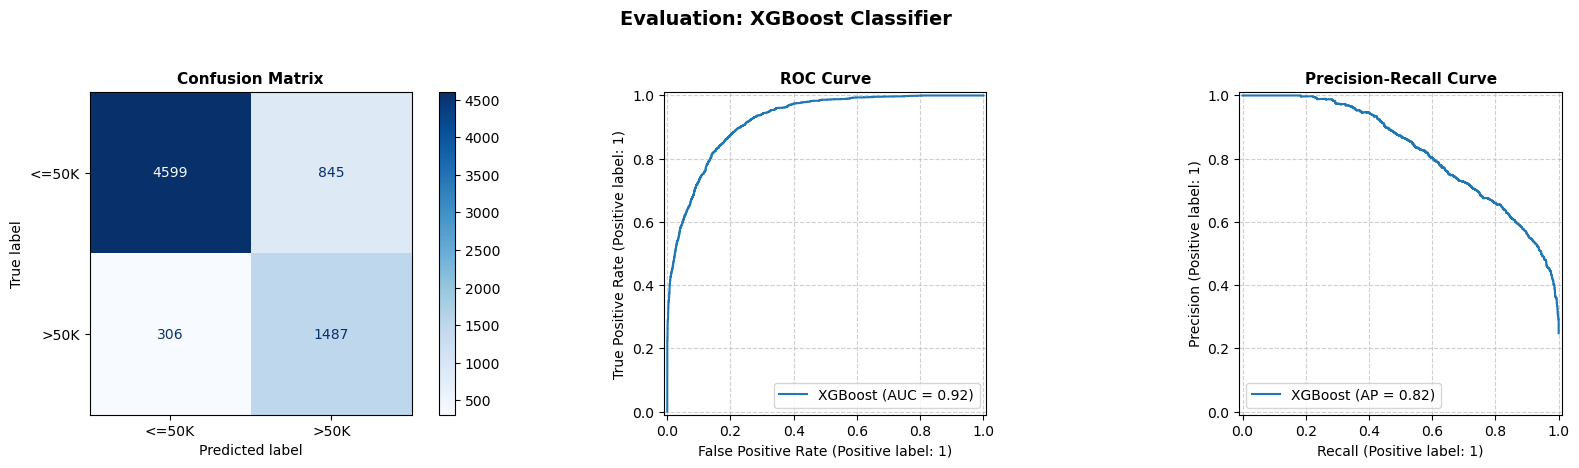

In [33]:
x_test_xgb = x_test[model_xgb.feature_names_in_]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle(
    "Evaluation: XGBoost Classifier", fontsize=14, fontweight="bold", y=1.03
)

ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    x_test_xgb,
    y_test,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")

RocCurveDisplay.from_estimator(
    model_xgb, x_test_xgb, y_test, ax=axes[1], name="XGBoost"
)
axes[1].set_title("ROC Curve", fontsize=11, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

PrecisionRecallDisplay.from_estimator(
    model_xgb, x_test_xgb, y_test, ax=axes[2], name="XGBoost"
)
axes[2].set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Implementasi model

In [34]:
path_file = r'C:\Bita\Lab\BigDataLab\seleksi_tes\test.csv'
df_test = pd.read_csv(path_file)
display(df_test.head(), df_test.shape)

,id,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0,30,Private,378009,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States
1,1,54,State-gov,55861,Assoc-acdm,12,Divorced,Adm-clerical,Not-in-family,White,Male,0,0,39,United-States
2,2,21,?,204226,Some-college,10,Never-married,?,Unmarried,White,Female,0,0,35,United-States
3,3,35,Private,306678,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,2885,0,40,United-States
4,4,42,Local-gov,121012,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States


(9769, 15)

In [35]:
test_id = df_test['id'].copy() 

In [36]:
df_test_ = df_test[df_test != '?']
print(df_test_.shape)
df_test_encoded = pd.get_dummies(df_test_, columns=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country'], drop_first=True)
print(df_test_encoded.shape)
df_test_encoded.head(10)

(9769, 15)
(9769, 97)


,id,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0,30,378009,9,0,0,40,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,1,54,55861,12,0,0,39,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,2,21,204226,10,0,0,35,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,3,35,306678,9,2885,0,40,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,4,42,121012,10,0,0,45,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,5,26,195105,9,0,0,40,False,False,True,...,False,False,False,False,False,False,False,True,False,False
6,6,50,321822,15,0,0,75,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,7,34,106014,10,0,0,40,False,False,True,...,False,False,False,False,False,False,False,True,False,False
8,8,29,200928,9,0,0,40,False,False,True,...,False,False,False,False,False,False,False,True,False,False
9,9,35,61518,9,0,0,35,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [37]:
bool_cols = df_test_encoded.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_test_encoded[col] = df_test_encoded[col].astype(int)
df_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9769 entries, 0 to 9768
Data columns (total 97 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id                                         9769 non-null   int64
 1   age                                        9769 non-null   int64
 2   fnlwgt                                     9769 non-null   int64
 3   education-num                              9769 non-null   int64
 4   capital-gain                               9769 non-null   int64
 5   capital-loss                               9769 non-null   int64
 6   hours-per-week                             9769 non-null   int64
 7   workclass_Local-gov                        9769 non-null   int64
 8   workclass_Never-worked                     9769 non-null   int64
 9   workclass_Private                          9769 non-null   int64
 10  workclass_Self-emp-inc                     9769 

In [38]:
df_test_encoded[num_cols] = scaler.transform(df_test_encoded[num_cols])
df_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9769 entries, 0 to 9768
Data columns (total 97 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         9769 non-null   int64  
 1   age                                        9769 non-null   float64
 2   fnlwgt                                     9769 non-null   float64
 3   education-num                              9769 non-null   float64
 4   capital-gain                               9769 non-null   float64
 5   capital-loss                               9769 non-null   float64
 6   hours-per-week                             9769 non-null   float64
 7   workclass_Local-gov                        9769 non-null   int64  
 8   workclass_Never-worked                     9769 non-null   int64  
 9   workclass_Private                          9769 non-null   int64  
 10  workclass_Self-emp-inc  

In [39]:
missing_cols = set(x_train.columns) - set(df_test_encoded.columns)
extra_cols = set(df_test_encoded.columns) - set(x_train.columns)
print('Missing columns in test:', missing_cols)
print('Extra columns in test:', extra_cols)

df_test_final = df_test_encoded.reindex(columns=x_train.columns, fill_value=0)
df_test_final.info()
df_test_final.head()

Missing columns in test: {'native-country_Holand-Netherlands'}
Extra columns in test: {'workclass_Never-worked', 'id'}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9769 entries, 0 to 9768
Data columns (total 96 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        9769 non-null   float64
 1   fnlwgt                                     9769 non-null   float64
 2   education-num                              9769 non-null   float64
 3   capital-gain                               9769 non-null   float64
 4   capital-loss                               9769 non-null   float64
 5   hours-per-week                             9769 non-null   float64
 6   workclass_Local-gov                        9769 non-null   int64  
 7   workclass_Private                          9769 non-null   int64  
 8   workclass_Self-emp-inc                     9769 n

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,-0.648173,1.782088,-0.438047,-0.146250,-0.221172,-0.079953,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1.167067,-1.269004,0.736617,-0.146250,-0.221172,-0.162981,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-1.328888,0.136174,-0.046493,-0.146250,-0.221172,-0.495091,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,-0.269998,1.106506,-0.438047,0.255939,-0.221172,-0.079953,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.259447,-0.651953,-0.046493,-0.146250,-0.221172,0.335186,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [40]:
y_pred_test = model_xgb.predict(df_test_final)

In [41]:
label_map = {0: '<=50K', 1: '>50K'}
y_pred_label = pd.Series(y_pred_test).map(label_map)

submission = pd.DataFrame({
    'id': test_id,
    'income': y_pred_label
})

print(submission.shape)
print(submission['income'].unique())
print(submission.head())

(9769, 2)
['<=50K' '>50K']
   id income
0   0  <=50K
1   1  <=50K
2   2  <=50K
3   3  <=50K
4   4   >50K


In [43]:
submission.to_csv('Submission3.csv ', index=False)
